**Publication execution note:** Existing outputs are historical and were preserved, not regenerated. Inputs resolve relative to the publication layout. New runs write to unique `runs/` directories, never to published models or results.

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

**Independent evaluation without retraining:** Restart the kernel and run ONLY the final code cell tagged `evaluation-only`. It is self-contained and loads the published model. Earlier code cells are tagged `retained-training` and blocked by default; explicit `RUN_RETAINED_TRAINING = True` is required to use them.

# CNN for *Candida albicans* AFM Force-Distance Curve Classification
## Balanced dataset — L2-regularised model

This notebook implements the controlled **L2 regularisation ablation** for three-class
classification of atomic force microscopy (AFM) force-distance curve images.

The architecture, dataset split, image preprocessing, random seed, optimizer, learning rate,
batch size, number of epochs, checkpoint criterion, validation protocol, blind-test protocol,
and complete-force-map inference protocol are kept identical to the balanced baseline.

The **only modelling change** relative to the baseline is the addition of L2 kernel
regularisation with **λ = 0.001**, matching the L2-only configuration used in the original
weight-regularisation notebook. L2 is applied to the five convolutional layers and the two
hidden dense layers. The three-unit Softmax output layer remains unregularised.

**Training/validation cell:** one *Candida albicans* cell is used to construct the balanced
training and validation dataset.

**Independent cell:** a second, previously unseen *C. albicans* cell is used for independent
evaluation. From this same second cell, 900 curves (300 per class) form the anonymised blind
test, while the complete 128 × 128 AFM force map contains 16,384 curves.

The best model, selected according to minimum validation loss, is saved as:

`Models/CNN_CAlbicans_Balanced_L2.h5`

In [1]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/balanced/l2.h5"
_run_parent = PROJECT_ROOT / "runs/balanced/l2"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))

# Reproducibility and experiment configuration
from pathlib import Path
import os
import shutil
import zipfile
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Request deterministic TensorFlow operations when supported.
# This improves run-to-run reproducibility on the same software/hardware stack.
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations: enabled")
except Exception as exc:
    print(f"TensorFlow deterministic operations could not be enabled: {exc}")

# -------------------------------------------------------------------------
# Main hyperparameters shared with the ablation-study variants
# -------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
L2_FACTOR = 1e-3

# -------------------------------------------------------------------------
# Relative paths: keep the ZIP files next to this notebook or edit here.
# -------------------------------------------------------------------------
DATA_ZIP = (DATA_DIR / "candida_balanced_dataset.zip")
TEST_ZIP = (DATA_DIR / "candida_cross_cell_test_balanced_original.zip")
FULL_MAP_ZIP = (DATA_DIR / "candida_full_force_map_128x128.zip")

WORK_DIR = (RUN_DIR / "work")
TRAIN_EXTRACT_DIR = WORK_DIR / "training"
TEST_EXTRACT_DIR = WORK_DIR / "testing"
FULL_MAP_EXTRACT_DIR = WORK_DIR / "full_map"

MODEL_DIR = (RUN_DIR / "models")
RESULTS_DIR = (RUN_DIR / "results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "l2.h5"

print(f"TensorFlow version: {tf.__version__}")
print(f"Model output path: {MODEL_PATH}")
print(f"L2 regularisation factor: {L2_FACTOR}")

gpus = tf.config.list_physical_devices("GPU")
print("GPU(s):", gpus if gpus else "No GPU detected")

2026-08-24 20:35:26.824527: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-24 20:35:26.871141: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-24 20:35:26.871176: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-24 20:35:26.872589: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-24 20:35:26.879733: I tensorflow/core/platform/cpu_feature_guar

TensorFlow deterministic operations: enabled
TensorFlow version: 2.15.0
Model output path: Models/CNN_CAlbicans_Balanced_L2.h5
L2 regularisation factor: 0.001
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-08-24 20:35:28.736357: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:29.013070: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:29.013142: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

def extract_zip_clean(zip_path, destination):
    """Extract a ZIP archive into a clean destination directory."""
    zip_path = Path(zip_path)
    destination = Path(destination)

    if not zip_path.exists():
        raise FileNotFoundError(
            f"{zip_path} was not found. Place it next to the notebook "
            "or modify the corresponding path in the configuration cell."
        )

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destination)

    return destination


def locate_class_root(search_root, expected_classes):
    """Locate the directory that directly contains all expected class folders."""
    search_root = Path(search_root)
    expected = set(expected_classes)

    candidates = [search_root] + [p for p in search_root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        children = {p.name for p in candidate.iterdir() if p.is_dir()}
        if expected.issubset(children):
            return candidate

    raise RuntimeError(
        f"Could not find a directory containing the class folders {sorted(expected)} "
        f"inside {search_root}."
    )


def class_names_from_iterator(iterator):
    """Return class names ordered according to the integer labels used by Keras."""
    return [
        name
        for name, idx in sorted(iterator.class_indices.items(), key=lambda item: item[1])
    ]


def plot_training_history(history):
    """Plot training/validation accuracy and loss."""
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1. Balanced training and validation dataset

The source dataset contains 3,000 force-distance curve images:

- 1,000 Intermediate
- 1,000 Nanodomain
- 1,000 Outside

An 80:20 hold-out split is used, yielding 2,400 training images and 600 validation images.
Only pixel rescaling to `[0, 1]` is applied in this baseline; no data augmentation is used.

In [3]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

EXPECTED_CLASSES = ["Intermediate", "Nanodomain", "Outside"]

extract_zip_clean(DATA_ZIP, TRAIN_EXTRACT_DIR)
base_dir = locate_class_root(TRAIN_EXTRACT_DIR, EXPECTED_CLASSES)

print("Training dataset root:", base_dir)

# Same generator object and same split definition will be used in the ablation variants.
data_generator = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.20,
)

train_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="training",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
)

validation_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="validation",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
)

CLASS_NAMES = class_names_from_iterator(validation_iterator)

print("Class indices:", validation_iterator.class_indices)
print("Ordered classes:", CLASS_NAMES)
print("Training samples:", train_iterator.samples)
print("Validation samples:", validation_iterator.samples)

assert train_iterator.samples == 2400, (
    f"Expected 2400 training images, found {train_iterator.samples}."
)
assert validation_iterator.samples == 600, (
    f"Expected 600 validation images, found {validation_iterator.samples}."
)
assert len(CLASS_NAMES) == 3

Training dataset root: /tmp/CNN_CAlbicans_Balanced_L2/training/Data_Adrian
Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Class indices: {'Intermediate': 0, 'Nanodomain': 1, 'Outside': 2}
Ordered classes: ['Intermediate', 'Nanodomain', 'Outside']
Training samples: 2400
Validation samples: 600


### Optional visual check of one image from each class

This check confirms the source images and their original dimensions before Keras resizes
them to `224 × 224 × 3` for the CNN.

Intermediate: Intermediate1.jpg -> original shape (676, 628, 3)


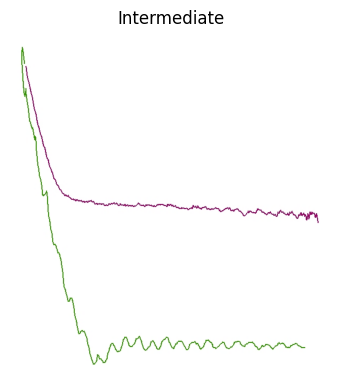

Nanodomain: Nanodomain1.jpg -> original shape (676, 628, 3)


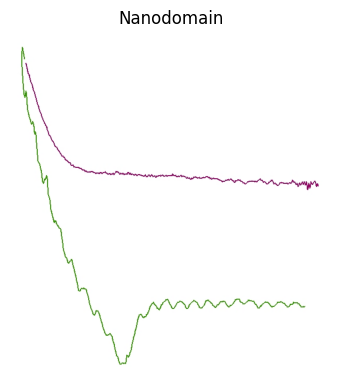

Outside: Outside1.jpg -> original shape (676, 628, 3)


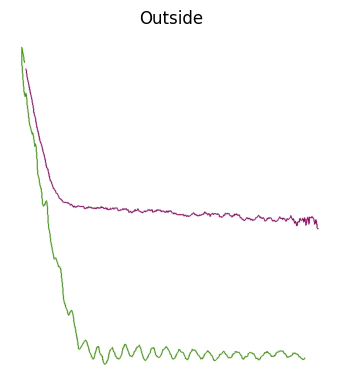

In [4]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

for class_name in CLASS_NAMES:
    class_dir = base_dir / class_name
    image_files = sorted(
        p for p in class_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    )
    if not image_files:
        raise RuntimeError(f"No image files found in {class_dir}")

    sample_path = image_files[0]
    img = tf.keras.utils.load_img(sample_path)
    arr = tf.keras.utils.img_to_array(img)

    print(f"{class_name}: {sample_path.name} -> original shape {arr.shape}")

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 2. CNN architecture with L2 kernel regularisation

The network architecture is identical to the balanced baseline:

- input: 224 × 224 × 3;
- five convolutional layers with 32, 64, 128, 256, and 256 filters;
- four 2 × 2 max-pooling layers;
- hidden dense layers with 512 and 128 units;
- three-unit Softmax output.

For this controlled ablation, **L2 kernel regularisation (λ = 0.001)** is applied to all five
convolutional layers and both hidden dense layers. No dropout or data augmentation is used.
The Softmax output layer is not regularised.

In [5]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Clear previous TensorFlow/Keras graph state and restore the same fixed seed
# immediately before model construction.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="fd_curve_image"
)

# Exact L2-only coefficient used in the original regularisation experiment.
l2_regularizer = tf.keras.regularizers.l2(L2_FACTOR)

x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_32"
)(inputs)
x = layers.MaxPooling2D((2, 2), name="pool_1")(x)

x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_64"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_2")(x)

x = layers.Conv2D(
    128, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_128"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_3")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_1"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_4")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_2"
)(x)

x = layers.Flatten(name="flatten")(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_512"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_128"
)(x)

# Output layer intentionally left unregularised.
outputs = layers.Dense(
    3,
    activation="softmax",
    name="class_probabilities"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN_CAlbicans_Balanced_L2"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

# L2 changes the objective, not the number of trainable parameters.
print("Total parameters:", model.count_params())

assert model.count_params() == 14_152_259, (
    "Unexpected parameter count. The controlled architecture may have changed."
)

# Verify that L2 is applied only to the intended seven layers.
regularised_layers = [
    layer.name
    for layer in model.layers
    if getattr(layer, "kernel_regularizer", None) is not None
]

expected_regularised_layers = [
    "conv_32",
    "conv_64",
    "conv_128",
    "conv_256_1",
    "conv_256_2",
    "dense_512",
    "dense_128",
]

assert regularised_layers == expected_regularised_layers, (
    f"Unexpected regularised layers: {regularised_layers}"
)

assert (
    model.get_layer("class_probabilities").kernel_regularizer is None
), "The Softmax output layer should remain unregularised."

print("L2-regularised layers:", regularised_layers)
print("L2 factor:", L2_FACTOR)

2026-08-24 20:35:49.913532: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:49.913800: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:49.913869: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:50.185467: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-24 20:35:50.185557: I external/local_xla/xla/stream_executor

Model: "CNN_CAlbicans_Balanced_L2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fd_curve_image (InputLayer  [(None, 224, 224, 3)]     0         
 )                                                               
                                                                 
 conv_32 (Conv2D)            (None, 222, 222, 32)      896       
                                                                 
 pool_1 (MaxPooling2D)       (None, 111, 111, 32)      0         
                                                                 
 conv_64 (Conv2D)            (None, 109, 109, 64)      18496     
                                                                 
 pool_2 (MaxPooling2D)       (None, 54, 54, 64)        0         
                                                                 
 conv_128 (Conv2D)           (None, 52, 52, 128)       73856     
                                         

## 3. Training

The best full model is selected using the **minimum validation loss** and saved as
`CNN_CAlbicans_Balanced_L2.h5`.

`steps_per_epoch` and `validation_steps` are intentionally omitted. Keras therefore
processes the complete training and validation iterators, including the final validation
batch of 24 images (`600 = 18×32 + 24`).

In [6]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

start_time = time.perf_counter()

history = model.fit(
    train_iterator,
    epochs=EPOCHS,
    validation_data=validation_iterator,
    callbacks=[checkpoint],
    verbose=1,
)

training_time_minutes = (time.perf_counter() - start_time) / 60.0
print(f"Total training time: {training_time_minutes:.2f} minutes")

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"
history_df.to_csv(RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_history.csv")

best_epoch = int(history_df["val_loss"].idxmin())
best_val_loss = float(history_df.loc[best_epoch, "val_loss"])
best_val_accuracy_during_fit = float(history_df.loc[best_epoch, "val_accuracy"])

training_summary = {
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "regularisation": "L2",
    "l2_factor": L2_FACTOR,
    "training_samples": int(train_iterator.samples),
    "validation_samples": int(validation_iterator.samples),
    "training_time_minutes": training_time_minutes,
    "best_epoch_by_val_loss": best_epoch,
    "best_val_loss": best_val_loss,
    "val_accuracy_at_best_val_loss_epoch": best_val_accuracy_during_fit,
    "model_path": str(MODEL_PATH),
}

with open(RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

print(training_summary)

Epoch 1/50


2026-08-24 20:35:57.024086: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-08-24 20:35:57.820504: I external/local_xla/xla/service/service.cc:168] XLA service 0x7199220f2460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-24 20:35:57.820555: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 5000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-08-24 20:35:57.827542: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787625357.907099  144598 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 [==============================] - ETA: 0s - loss: 1.5916 - accuracy: 0.9404
Epoch 1: val_loss improved from inf to 1.15944, saving model to Models/CNN_CAlbicans_Balanced_L2.h5


/home/adrian/anaconda3/envs/TFQ/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


75/75 [==============================] - 13s 118ms/step - loss: 1.5916 - accuracy: 0.9404 - val_loss: 1.1594 - val_accuracy: 0.9700
Epoch 2/50
75/75 [==============================] - ETA: 0s - loss: 0.9642 - accuracy: 0.9892
Epoch 2: val_loss improved from 1.15944 to 0.88639, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [==============================] - 9s 120ms/step - loss: 0.9642 - accuracy: 0.9892 - val_loss: 0.8864 - val_accuracy: 0.9833
Epoch 3/50
75/75 [==============================] - ETA: 0s - loss: 0.7683 - accuracy: 0.9933
Epoch 3: val_loss improved from 0.88639 to 0.73036, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [==============================] - 9s 117ms/step - loss: 0.7683 - accuracy: 0.9933 - val_loss: 0.7304 - val_accuracy: 0.9883
Epoch 4/50
75/75 [==============================] - ETA: 0s - loss: 0.6573 - accuracy: 0.9933
Epoch 4: val_loss improved from 0.73036 to 0.63579, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [=====

75/75 [==============================] - 8s 103ms/step - loss: 0.1289 - accuracy: 0.9950 - val_loss: 0.1546 - val_accuracy: 0.9900
Epoch 27/50
75/75 [==============================] - ETA: 0s - loss: 0.1240 - accuracy: 0.9942
Epoch 27: val_loss improved from 0.15458 to 0.15257, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [==============================] - 8s 105ms/step - loss: 0.1240 - accuracy: 0.9942 - val_loss: 0.1526 - val_accuracy: 0.9833
Epoch 28/50
75/75 [==============================] - ETA: 0s - loss: 0.1198 - accuracy: 0.9942
Epoch 28: val_loss improved from 0.15257 to 0.14018, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [==============================] - 8s 102ms/step - loss: 0.1198 - accuracy: 0.9942 - val_loss: 0.1402 - val_accuracy: 0.9900
Epoch 29/50
75/75 [==============================] - ETA: 0s - loss: 0.1131 - accuracy: 0.9954
Epoch 29: val_loss improved from 0.14018 to 0.13151, saving model to Models/CNN_CAlbicans_Balanced_L2.h5
75/75 [

### 3.1. Training and validation loss

The L2 training and validation loss curves are plotted independently after training, using
the same simple presentation as the original regularisation experiment. Because this is an
L2 model, the Keras `loss` and `val_loss` values include the L2 penalty.

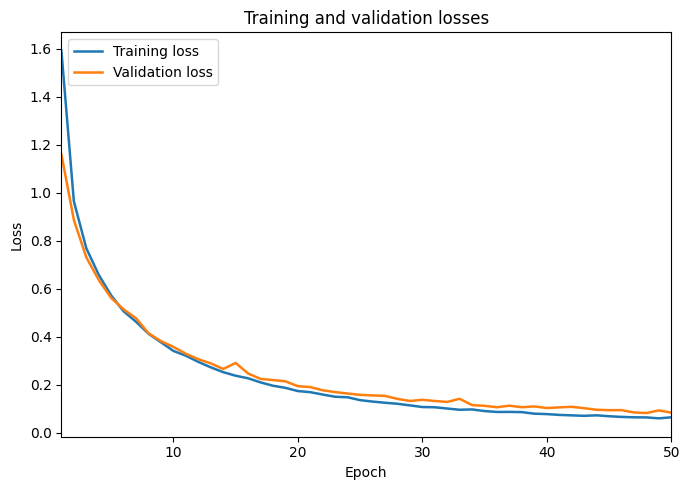

Best epoch by validation loss: 48
Minimum validation loss: 0.081130
Figure saved to: Results/CNN_CAlbicans_Balanced_L2_Loss.png


In [7]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Training and validation loss — original-paper style

history_df_plot = pd.DataFrame(history.history)
epochs_axis = np.arange(1, len(history_df_plot) + 1)

best_epoch_plot = int(
    np.argmin(history_df_plot["val_loss"].to_numpy()) + 1
)
best_val_loss_plot = float(
    history_df_plot.loc[best_epoch_plot - 1, "val_loss"]
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs_axis,
    history_df_plot["loss"],
    linewidth=1.8,
    label="Training loss"
)

ax.plot(
    epochs_axis,
    history_df_plot["val_loss"],
    linewidth=1.8,
    label="Validation loss"
)

ax.set_title("Training and validation losses")
ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")
ax.set_xlim(1, len(epochs_axis))
ax.legend(loc="upper left")

fig.tight_layout()

loss_figure_path = (
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_Loss.png"
)

fig.savefig(
    loss_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best epoch by validation loss: {best_epoch_plot}")
print(f"Minimum validation loss: {best_val_loss_plot:.6f}")
print(f"Figure saved to: {loss_figure_path}")

### 3.2. Training and validation accuracy

Training and validation accuracies are shown independently using the presentation of the
original L2 experiment. The y-axis is left on automatic scaling so that the actual degree of
convergence between the two curves remains visible.

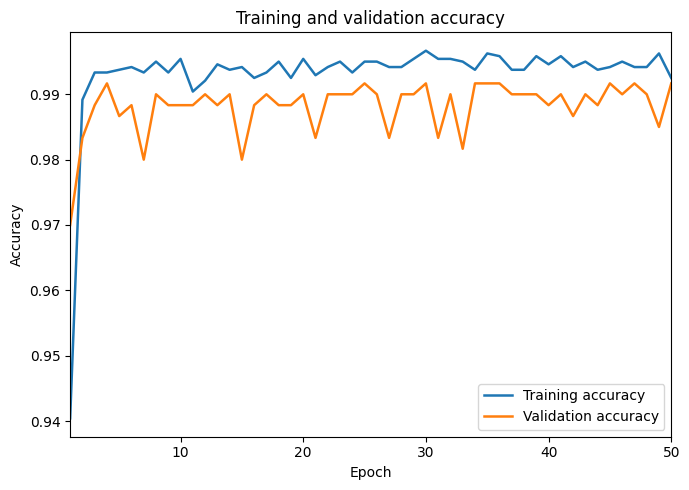

Validation accuracy at the best-loss epoch: 0.990000
Figure saved to: Results/CNN_CAlbicans_Balanced_L2_Accuracy.png


In [8]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Training and validation accuracy — original-paper style

history_df_plot = pd.DataFrame(history.history)
epochs_axis = np.arange(1, len(history_df_plot) + 1)

best_epoch_plot = int(
    np.argmin(history_df_plot["val_loss"].to_numpy()) + 1
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs_axis,
    history_df_plot["accuracy"],
    linewidth=1.8,
    label="Training accuracy"
)

ax.plot(
    epochs_axis,
    history_df_plot["val_accuracy"],
    linewidth=1.8,
    label="Validation accuracy"
)

ax.set_title("Training and validation accuracy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")
ax.set_xlim(1, len(epochs_axis))
ax.legend(loc="lower right")

fig.tight_layout()

accuracy_figure_path = (
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_Accuracy.png"
)

fig.savefig(
    accuracy_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Validation accuracy at the best-loss epoch: "
    f"{history_df_plot.loc[best_epoch_plot - 1, 'val_accuracy']:.6f}"
)
print(f"Figure saved to: {accuracy_figure_path}")

## 4. Validation performance

All 600 validation images are evaluated using the saved best `.h5` L2 model.

The minimum `val_loss` is used to select the best checkpoint **within this L2 experiment**.
Because Keras includes the L2 penalty in `loss` and `val_loss`, raw loss values should not be
used as the main between-model comparison against the unregularised baseline. Validation
accuracy, precision, recall, F1 score, independent-cell performance, and training behaviour
are more appropriate for the ablation comparison.

In [9]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

best_model = load_model(MODEL_PATH)

validation_iterator.reset()
val_probabilities = best_model.predict(validation_iterator, verbose=1)
val_predictions = np.argmax(val_probabilities, axis=1)
val_true = validation_iterator.classes

assert len(val_predictions) == validation_iterator.samples == 600

val_accuracy = accuracy_score(val_true, val_predictions)
val_cm = confusion_matrix(val_true, val_predictions)

print(f"Validation accuracy: {val_accuracy:.4f}")
print("\nClassification report:")
print(
    classification_report(
        val_true,
        val_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

report_dict = classification_report(
    val_true,
    val_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
pd.DataFrame(report_dict).T.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_validation_report.csv"
)

validation_predictions = pd.DataFrame({
    "filename": validation_iterator.filenames,
    "true_label": [CLASS_NAMES[i] for i in val_true],
    "predicted_label": [CLASS_NAMES[i] for i in val_predictions],
})
for idx, class_name in enumerate(CLASS_NAMES):
    validation_predictions[f"prob_{class_name}"] = val_probabilities[:, idx]

validation_predictions.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_validation_predictions.csv",
    index=False,
)

19/19 [==============================] - 3s 167ms/step
Validation accuracy: 0.9900

Classification report:
              precision    recall  f1-score   support

Intermediate     0.9850    0.9850    0.9850       200
  Nanodomain     0.9950    0.9950    0.9950       200
     Outside     0.9900    0.9900    0.9900       200

    accuracy                         0.9900       600
   macro avg     0.9900    0.9900    0.9900       600
weighted avg     0.9900    0.9900    0.9900       600



### 4.1. Publication-style validation confusion matrix

The confusion matrix is plotted independently using the same visual format intended for
the manuscript. Raw counts are shown in each cell, correctly classified samples on the
main diagonal are labelled **True Positive**, and the overall validation accuracy is
reported below the x-axis. The figure is saved automatically at 300 dpi.

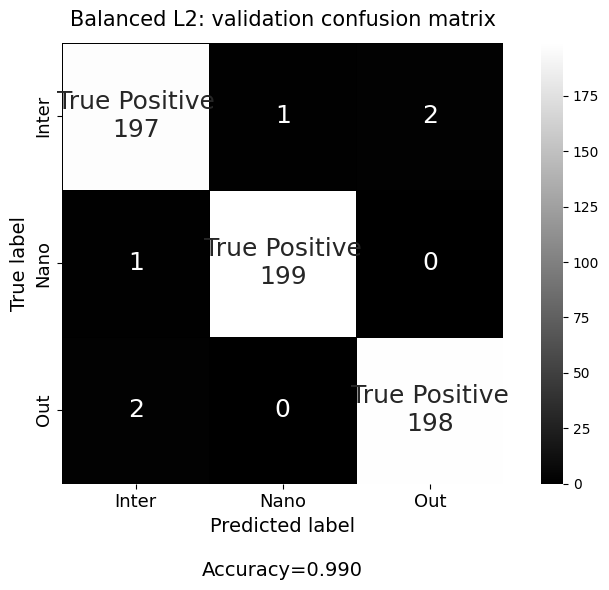

Publication-quality confusion matrix saved to: Results/CNN_CAlbicans_Balanced_L2_Validation_ConfusionMatrix.png


In [10]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Publication-style confusion matrix
import seaborn as sns

def make_confusion_matrix(
    cf,
    group_names=None,
    categories="auto",
    count=True,
    percent=False,
    cbar=True,
    xyticks=True,
    xyplotlabels=True,
    sum_stats=True,
    figsize=(8, 6),
    cmap="gray",
    title=None,
    save_path=None,
):
    """
    Create a publication-style heatmap from an sklearn confusion matrix.

    Parameters
    ----------
    cf : ndarray
        Confusion matrix.
    group_names : list[str] or None
        Optional text labels for individual matrix cells.
    categories : list[str] or 'auto'
        Class labels shown on the x and y axes.
    count : bool
        Show raw counts in each matrix cell.
    percent : bool
        Show the percentage of the complete matrix in each cell.
    cbar : bool
        Display the colour bar.
    xyticks : bool
        Display class tick labels.
    xyplotlabels : bool
        Display 'True label' and 'Predicted label'.
    sum_stats : bool
        Display overall accuracy below the matrix.
    figsize : tuple
        Matplotlib figure size.
    cmap : str
        Matplotlib/Seaborn colour map.
    title : str or None
        Figure title.
    save_path : str, Path, or None
        Optional output path. When provided, the figure is saved at 300 dpi.
    """

    cf = np.asarray(cf)

    blanks = ["" for _ in range(cf.size)]

    if group_names is not None and len(group_names) == cf.size:
        group_labels = [f"{value}\n" if value else "" for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = [f"{value:0.0f}\n" for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        total = float(np.sum(cf))
        if total > 0:
            group_percentages = [
                f"{value / total:.1%}" for value in cf.flatten()
            ]
        else:
            group_percentages = blanks
    else:
        group_percentages = blanks

    box_labels = [
        f"{label}{n}{pct}".strip()
        for label, n, pct in zip(
            group_labels,
            group_counts,
            group_percentages,
        )
    ]
    box_labels = np.asarray(box_labels).reshape(cf.shape)

    # Overall accuracy
    if sum_stats:
        total = float(np.sum(cf))
        accuracy = np.trace(cf) / total if total > 0 else np.nan
        stats_text = f"\n\nAccuracy={accuracy:0.3f}"
    else:
        stats_text = ""

    if not xyticks:
        categories = False

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        cf,
        annot=box_labels,
        fmt="",
        cmap=cmap,
        cbar=cbar,
        xticklabels=categories,
        yticklabels=categories,
        annot_kws={"fontsize": 18},
        linewidths=0.5,
        linecolor="black",
        square=True,
        ax=ax,
    )

    if xyplotlabels:
        ax.set_ylabel("True label", fontsize=14)
        ax.set_xlabel("Predicted label" + stats_text, fontsize=14)
    else:
        ax.set_xlabel(stats_text, fontsize=14)

    ax.tick_params(axis="both", labelsize=13)

    if title:
        ax.set_title(title, fontsize=15, pad=12)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    return ax


# Matrix already calculated from all 600 validation images:
# val_cm = confusion_matrix(val_true, val_predictions)

paper_cell_labels = [
    "True Positive", "", "",
    "", "True Positive", "",
    "", "", "True Positive",
]

paper_categories = ["Inter", "Nano", "Out"]

validation_cm_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_Validation_ConfusionMatrix.png"
)

make_confusion_matrix(
    val_cm,
    group_names=paper_cell_labels,
    categories=paper_categories,
    count=True,
    percent=False,
    cbar=True,
    xyticks=True,
    xyplotlabels=True,
    sum_stats=True,
    figsize=(8, 6),
    cmap="gray",
    title="Balanced L2: validation confusion matrix",
    save_path=validation_cm_path,
)

print(f"Publication-quality confusion matrix saved to: {validation_cm_path}")

## 5. Independent balanced blind test set from a second *Candida albicans* cell

The independent evaluation uses a **second *Candida albicans* cell that was not used for
training or validation**. From the AFM force map of this cell, 300 force-distance curves were
selected beforehand from each of the three experimentally defined nanoadhesive classes using
the AtomicJ ROI tool: 300 Intermediate, 300 Nanodomain, and 300 Outside.

The resulting 900 force-distance curve images were randomly mixed and anonymised as
`testing1.jpg` to `testing900.jpg` before inference. Consequently, neither the filenames nor
the directory structure provide class information to the CNN.

The CNN first performs **blind inference** on the 900 mixed images and stores the predicted
class and Softmax probabilities for each curve. If the separate hidden file
`cross_cell_label_mapping.csv` is available, the sample-level ground truth
(`filename,true_label`) is loaded **only after all predictions have been generated** to
calculate accuracy, precision, recall, F1 score, and the confusion matrix.

The complete 16,384-curve AFM force map classified in Section 6 originates from this **same
independent cell**, providing both a labelled 900-curve independent test and a full-map
high-throughput inference experiment on the same biological sample.

Independent blind-test images found: 900
First files: ['testing1.jpg', 'testing2.jpg', 'testing3.jpg', 'testing4.jpg', 'testing5.jpg']
Last files: ['testing896.jpg', 'testing897.jpg', 'testing898.jpg', 'testing899.jpg', 'testing900.jpg']

Loaded model: Models/CNN_CAlbicans_Balanced_L2.h5
29/29 [==============================] - 1s 14ms/step

Predicted class counts:
predicted_label
Intermediate    298
Nanodomain      300
Outside         302
Name: count, dtype: int64

Total blind-test inference time: 0.56 s
Average inference time per FD curve: 0.627 ms
Throughput: 1594.5 FD curves/s
Mean maximum predicted probability: 0.9941
Median maximum predicted probability: 0.9980

Blind predictions saved to: Results/CNN_CAlbicans_Balanced_L2_blind_test_predictions.csv


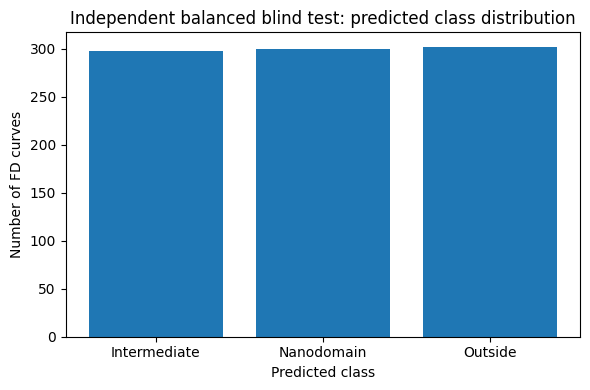


TestingAdrian_labels.csv was not found.
Blind inference was completed successfully.
Accuracy, precision, recall, F1 score, and confusion matrix will be calculated automatically once the hidden sample-level ground-truth CSV is available.


In [11]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# ============================================================
# 5. Independent balanced blind test set from a different cell
# ============================================================

import re

# Optional hidden ground-truth file.
# Format:
# filename,true_label
# testing1.jpg,Nanodomain
# testing2.jpg,Intermediate
# ...
GROUND_TRUTH_CSV = LABEL_MAPPING

# ------------------------------------------------------------
# 1. Extract the 900 anonymised test images
# ------------------------------------------------------------
extract_zip_clean(TEST_ZIP, TEST_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def natural_test_key(path):
    """Natural numeric ordering: testing1.jpg ... testing900.jpg."""
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(path).name)
    return int(match.group(1)) if match else Path(path).name

blind_test_files = sorted(
    [
        p for p in TEST_EXTRACT_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ],
    key=natural_test_key,
)

print(f"Independent blind-test images found: {len(blind_test_files)}")

if len(blind_test_files) != 900:
    raise RuntimeError(
        f"Expected 900 independent test images, found {len(blind_test_files)}."
    )

print("First files:", [p.name for p in blind_test_files[:5]])
print("Last files:", [p.name for p in blind_test_files[-5:]])

# ------------------------------------------------------------
# 2. Preprocess images exactly as in training/validation
# ------------------------------------------------------------
def load_blind_test_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

blind_test_paths = [str(p) for p in blind_test_files]

blind_test_dataset = (
    tf.data.Dataset.from_tensor_slices(blind_test_paths)
    .map(
        load_blind_test_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# 3. Reload the persisted best H5 model
# ------------------------------------------------------------
blind_test_model = load_model(MODEL_PATH)
print("\nLoaded model:", MODEL_PATH)

# Warm-up to avoid including one-time TensorFlow tracing/initialisation
# overhead in the inference-time measurement.
for warmup_batch in blind_test_dataset.take(1):
    _ = blind_test_model(warmup_batch, training=False)

# ------------------------------------------------------------
# 4. BLIND inference: no ground truth has been loaded
# ------------------------------------------------------------
test_start = time.perf_counter()

blind_test_probabilities = blind_test_model.predict(
    blind_test_dataset,
    verbose=1,
)

test_time_seconds = time.perf_counter() - test_start

blind_test_predictions = np.argmax(
    blind_test_probabilities,
    axis=1,
)

max_predicted_probability = np.max(
    blind_test_probabilities,
    axis=1,
)

# ------------------------------------------------------------
# 5. Save sample-level blind predictions
# ------------------------------------------------------------
blind_test_df = pd.DataFrame({
    "filename": [p.name for p in blind_test_files],
    "predicted_label": [CLASS_NAMES[i] for i in blind_test_predictions],
    "maximum_predicted_probability": max_predicted_probability,
})

for idx, class_name in enumerate(CLASS_NAMES):
    blind_test_df[f"prob_{class_name}"] = blind_test_probabilities[:, idx]

blind_predictions_path = (
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_blind_test_predictions.csv"
)

blind_test_df.to_csv(
    blind_predictions_path,
    index=False,
)

# ------------------------------------------------------------
# 6. Report predicted class distribution
# ------------------------------------------------------------
predicted_counts = (
    blind_test_df["predicted_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\nPredicted class counts:")
print(predicted_counts)

n_blind_test = len(blind_test_files)
blind_time_per_curve_ms = (test_time_seconds / n_blind_test) * 1000.0
blind_throughput = n_blind_test / test_time_seconds

print(f"\nTotal blind-test inference time: {test_time_seconds:.2f} s")
print(f"Average inference time per FD curve: {blind_time_per_curve_ms:.3f} ms")
print(f"Throughput: {blind_throughput:.1f} FD curves/s")
print(
    "Mean maximum predicted probability: "
    f"{max_predicted_probability.mean():.4f}"
)
print(
    "Median maximum predicted probability: "
    f"{np.median(max_predicted_probability):.4f}"
)
print(f"\nBlind predictions saved to: {blind_predictions_path}")

plt.figure(figsize=(6, 4))
plt.bar(predicted_counts.index, predicted_counts.values)
plt.ylabel("Number of FD curves")
plt.xlabel("Predicted class")
plt.title("Independent balanced blind test: predicted class distribution")
plt.tight_layout()
plt.show()

# ============================================================
# 7. OPTIONAL ground-truth evaluation
# ============================================================
# IMPORTANT:
# The CSV is loaded only AFTER all CNN predictions have been generated.
# Therefore the ground-truth labels cannot influence inference.
# ============================================================

if GROUND_TRUTH_CSV.exists():

    labels_df = pd.read_csv(GROUND_TRUTH_CSV)

    required_columns = {"filename", "true_label"}

    if not required_columns.issubset(labels_df.columns):
        raise ValueError(
            "cross_cell_label_mapping.csv must contain the columns: "
            "filename,true_label"
        )

    labels_df = labels_df[["filename", "true_label"]].copy()

    if labels_df["filename"].duplicated().any():
        raise ValueError(
            "Duplicate filenames were found in cross_cell_label_mapping.csv."
        )

    if len(labels_df) != 900:
        raise ValueError(
            f"Expected 900 ground-truth labels, found {len(labels_df)}."
        )

    invalid_labels = sorted(
        set(labels_df["true_label"]) - set(CLASS_NAMES)
    )

    if invalid_labels:
        raise ValueError(
            f"Unknown class labels: {invalid_labels}. "
            f"Expected only: {CLASS_NAMES}"
        )

    # Verify the intended balanced independent test: 300 samples per class.
    true_counts = (
        labels_df["true_label"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )

    print("\nGround-truth class distribution:")
    print(true_counts)

    if not (true_counts == 300).all():
        raise ValueError(
            "The balanced independent test must contain exactly "
            "300 images per class."
        )

    # Join labels only after inference.
    evaluated_df = blind_test_df.merge(
        labels_df,
        on="filename",
        how="left",
        validate="one_to_one",
    )

    if evaluated_df["true_label"].isna().any():
        missing = evaluated_df.loc[
            evaluated_df["true_label"].isna(),
            "filename",
        ].tolist()

        raise ValueError(
            f"Ground-truth labels are missing for {len(missing)} images. "
            f"Examples: {missing[:10]}"
        )

    y_true = evaluated_df["true_label"].to_numpy()
    y_pred = evaluated_df["predicted_label"].to_numpy()

    # --------------------------------------------------------
    # 8. Independent-cell classification metrics
    # --------------------------------------------------------
    test_accuracy = accuracy_score(y_true, y_pred)

    print("\n============================================")
    print("Independent balanced blind-test performance")
    print("============================================")
    print(f"Accuracy: {test_accuracy:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=CLASS_NAMES,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
    )

    print("\nConfusion matrix:")
    print(test_cm)

    independent_cm_path = (
        RESULTS_DIR
        / "CNN_CAlbicans_Balanced_L2_IndependentTest_ConfusionMatrix.png"
    )

    make_confusion_matrix(
        test_cm,
        group_names=paper_cell_labels,
        categories=paper_categories,
        count=True,
        percent=False,
        cbar=True,
        xyticks=True,
        xyplotlabels=True,
        sum_stats=True,
        figsize=(8, 6),
        cmap="gray",
        title="Independent balanced blind-test confusion matrix",
        save_path=independent_cm_path,
    )

    print(
        f"Independent-test confusion matrix saved to: "
        f"{independent_cm_path}"
    )

    # Save metrics.
    test_report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    pd.DataFrame(test_report).T.to_csv(
        RESULTS_DIR
        / "CNN_CAlbicans_Balanced_L2_independent_test_report.csv"
    )

    evaluated_df.to_csv(
        RESULTS_DIR
        / "CNN_CAlbicans_Balanced_L2_independent_test_predictions_with_ground_truth.csv",
        index=False,
    )

    print("\nSupervised independent-test metrics saved in Results/.")

else:
    print(
        "\ncross_cell_label_mapping.csv was not found."
        "\nBlind inference was completed successfully."
        "\nAccuracy, precision, recall, F1 score, and confusion matrix "
        "will be calculated automatically once the hidden "
        "sample-level ground-truth CSV is available."
    )

## 6. Classification of the complete 16,384-curve AFM force map from the same independent cell

The complete 128 × 128 AFM force map used in this section contains **16,384 force-distance
curves from the same second *Candida albicans* cell used to construct the 900-curve blind
test set in Section 5**.

Unlike the 900-curve subset, the complete force map is treated as an unlabeled operational
dataset. All images are resized to 224 × 224 pixels, rescaled to `[0,1]`, and classified by
the persisted best `.h5` model.

Inference time is measured **after model loading and after a warm-up pass**, so the reported
time reflects prediction rather than one-time TensorFlow tracing or initialisation overhead.
The same timing protocol should be used for all subsequent ablation-study models.

Full-map images found: 16384
512/512 [==============================] - 6s 12ms/step
Full-map class counts: {'Intermediate': 3765, 'Nanodomain': 8180, 'Outside': 4439}
Total inference time for 16,384 FD curves: 6.82 s
Average inference time per FD curve: 0.416 ms
Throughput: 2401.3 FD curves/s


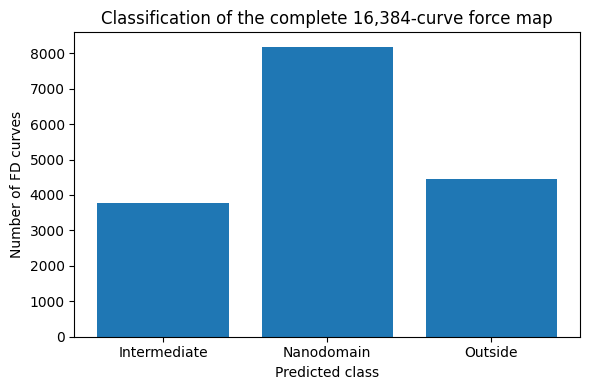

In [12]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

extract_zip_clean(FULL_MAP_ZIP, FULL_MAP_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
full_map_files = sorted(
    p
    for p in FULL_MAP_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
)

print("Full-map images found:", len(full_map_files))
if len(full_map_files) != 16_384:
    raise RuntimeError(
        f"Expected 16,384 force-distance curve images, found {len(full_map_files)}."
    )

full_map_paths = [str(p) for p in full_map_files]

def load_and_preprocess_unlabelled_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

full_map_dataset = (
    tf.data.Dataset.from_tensor_slices(full_map_paths)
    .map(
        load_and_preprocess_unlabelled_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Warm-up to reduce one-time tracing/initialisation overhead in the timed measurement.
for warmup_batch in full_map_dataset.take(1):
    _ = best_model(warmup_batch, training=False)

full_map_start = time.perf_counter()
full_map_probabilities = best_model.predict(full_map_dataset, verbose=1)
full_map_time_seconds = time.perf_counter() - full_map_start

full_map_predictions = np.argmax(full_map_probabilities, axis=1)

unique, counts = np.unique(full_map_predictions, return_counts=True)
class_counts = {
    CLASS_NAMES[int(class_idx)]: int(count)
    for class_idx, count in zip(unique, counts)
}

n_full_map = len(full_map_files)
full_map_time_per_curve_ms = (full_map_time_seconds / n_full_map) * 1000.0
full_map_throughput = n_full_map / full_map_time_seconds

print("Full-map class counts:", class_counts)
print(
    f"Total inference time for {n_full_map:,} FD curves: "
    f"{full_map_time_seconds:.2f} s"
)
print(f"Average inference time per FD curve: {full_map_time_per_curve_ms:.3f} ms")
print(f"Throughput: {full_map_throughput:.1f} FD curves/s")

full_map_df = pd.DataFrame({
    "filename": [p.name for p in full_map_files],
    "predicted_label": [CLASS_NAMES[i] for i in full_map_predictions],
})
for idx, class_name in enumerate(CLASS_NAMES):
    full_map_df[f"prob_{class_name}"] = full_map_probabilities[:, idx]

full_map_df.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Balanced_L2_full_map_predictions.csv",
    index=False,
)

plt.figure(figsize=(6, 4))
plt.bar(list(class_counts.keys()), list(class_counts.values()))
plt.ylabel("Number of FD curves")
plt.xlabel("Predicted class")
plt.title("Classification of the complete 16,384-curve force map")
plt.tight_layout()
plt.show()

### 6.1. Computational performance summary

This cell consolidates the training time and the two inference experiments performed with
the persisted baseline model: the 900-curve blind independent test and the complete
16,384-curve force map from the same second *Candida albicans* cell.

In [13]:
if not globals().get("RUN_RETAINED_TRAINING", False):
    raise RuntimeError("Retained training is disabled. For independent evaluation, run only the final evaluation-only cell.")

# Consolidated computational-performance summary

performance_summary = {
    "model": "CNN_CAlbicans_Balanced_L2",
    "training_time_minutes": float(training_time_minutes),
    "blind_test_curves": int(len(blind_test_files)),
    "blind_test_inference_time_seconds": float(test_time_seconds),
    "blind_test_time_per_curve_ms": float(blind_time_per_curve_ms),
    "blind_test_throughput_curves_per_second": float(blind_throughput),
    "full_map_curves": int(len(full_map_files)),
    "full_map_inference_time_seconds": float(full_map_time_seconds),
    "full_map_time_per_curve_ms": float(full_map_time_per_curve_ms),
    "full_map_throughput_curves_per_second": float(full_map_throughput),
}

performance_df = pd.DataFrame([performance_summary])
display(performance_df)

performance_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_ComputationalPerformance.csv"
)

performance_df.to_csv(performance_path, index=False)

print(f"Computational-performance summary saved to: {performance_path}")

,model,training_time_minutes,blind_test_curves,blind_test_inference_time_seconds,blind_test_time_per_curve_ms,blind_test_throughput_curves_per_second,full_map_curves,full_map_inference_time_seconds,full_map_time_per_curve_ms,full_map_throughput_curves_per_second
0,CNN_CAlbicans_Balanced_L2,6.946511,900,0.564424,0.627137,1594.546763,16384,6.82302,0.416444,2401.282561


Computational-performance summary saved to: Results/CNN_CAlbicans_Balanced_L2_ComputationalPerformance.csv


## 7. Output files

After a complete run, the notebook produces:

- `Models/CNN_CAlbicans_Balanced_L2.h5`
- L2 training history and training summary
- independent L2 loss and accuracy figures
- publication-style validation confusion matrix
- validation classification report and sample-level predictions
- 900-curve blind-test predictions from the second *C. albicans* cell
- optional independent-test metrics and confusion matrix when
  `cross_cell_label_mapping.csv` is available
- complete 16,384-curve force-map predictions from the **same independent cell**
- computational-performance summary including total inference time, time per curve, and
  throughput for both the 900-curve and 16,384-curve experiments

The `.h5` file is the best L2 checkpoint selected by minimum validation loss.

For the ablation study, this notebook should be compared with the baseline using the same
seed, data split, hardware, preprocessing, batch size, learning rate, epoch limit, checkpoint
criterion, validation set, blind test, and complete force map.

## Independent cross-cell evaluation: restored experimental class-file organization

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

Use the final self-contained evaluation cell with the published H5 and cross_cell_label_mapping.csv.


Labelled test ZIP: /home/adrian/anaconda3/envs/TFQ/Archivos/CNN/TestingAdrian_Labelled.zip
Labels CSV: /home/adrian/anaconda3/envs/TFQ/Archivos/CNN/TestingAdrian_labels.csv
Persisted CNN-L2 model: Models/CNN_CAlbicans_Balanced_L2.h5
Ground-truth class counts: {'Intermediate': 300, 'Nanodomain': 300, 'Outside': 300}
Class order used by the CNN: ['Intermediate', 'Nanodomain', 'Outside']
29/29 [==============================] - 1s 19ms/step

Independent cross-cell sample-level performance
------------------------------------------------
Accuracy:          0.9978
Balanced accuracy: 0.9978
Macro F1:          0.9978
Weighted F1:       0.9978

Classification report:
              precision    recall  f1-score   support

Intermediate     1.0000    0.9933    0.9967       300
  Nanodomain     1.0000    1.0000    1.0000       300
     Outside     0.9934    1.0000    0.9967       300

    accuracy                         0.9978       900
   macro avg     0.9978    0.9978    0.9978       900
weight

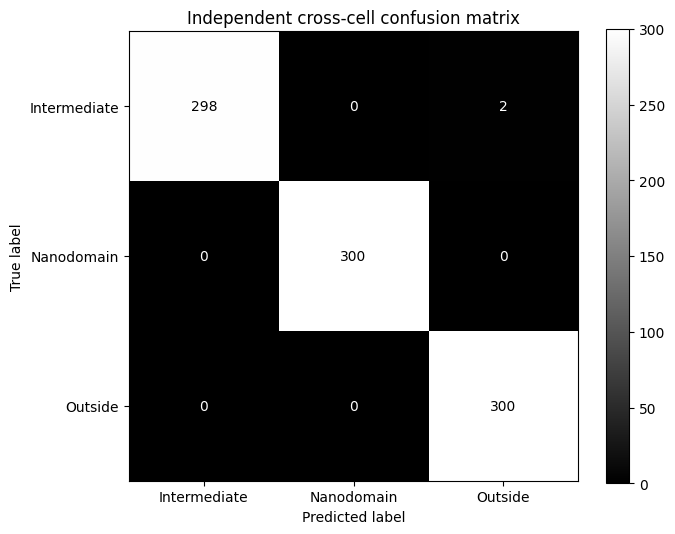

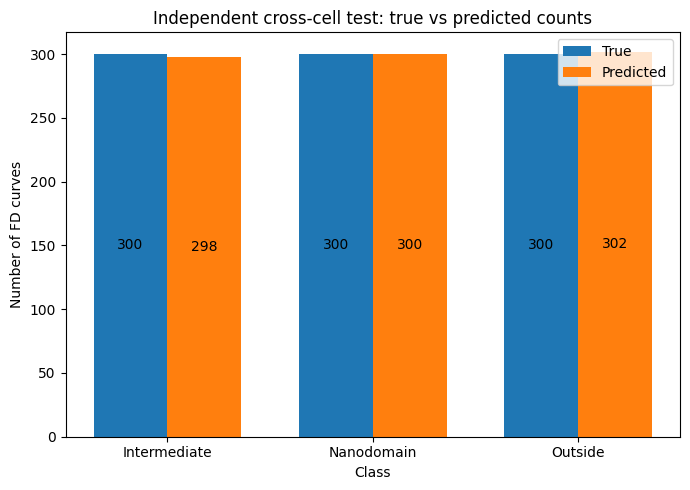


Inference time for 900 independent curves: 0.93 s
Average time per curve: 1.037 ms
Throughput: 964.5 curves/s


In [2]:
# ============================================================
# Independent cross-cell sample-level evaluation (900 curves)
# SELF-CONTAINED: this cell can be run even after restarting the kernel.
# ============================================================

from pathlib import Path
import shutil
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

# -------------------------------------------------------------------------
# Self-contained experiment configuration
# -------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32

CROSS_CELL_CLASS_NAMES = [
    "Intermediate",
    "Nanodomain",
    "Outside",
]

# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/balanced/l2.h5"
_run_parent = PROJECT_ROOT / "runs/balanced/l2"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))
RESULTS_DIR = RUN_DIR / "cross_cell"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LABELLED_TEST_ZIP = DATA_DIR / "candida_cross_cell_test_balanced_labelled.zip"
LABELS_CSV = LABEL_MAPPING
MODEL_PATH = PUBLISHED_MODEL
if not MODEL_PATH.is_file():
    raise FileNotFoundError(MODEL_PATH)
LABELLED_TEST_EXTRACT_DIR = RUN_DIR / "labelled_test"

# -------------------------------------------------------------------------
# Extract the restored experimental test organization
# -------------------------------------------------------------------------
if LABELLED_TEST_EXTRACT_DIR.exists():
    shutil.rmtree(LABELLED_TEST_EXTRACT_DIR)

LABELLED_TEST_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(LABELLED_TEST_ZIP, "r") as zf:
    zf.extractall(LABELLED_TEST_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

all_images = [
    p for p in LABELLED_TEST_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
]

# The ZIP contains both a flat Test/ copy and a by_class/ copy.
# Use only the flat Test/ directory to avoid duplicate images.
flat_test_files = [
    p for p in all_images
    if p.parent.name == "Test"
]

if len(flat_test_files) != 900:
    raise RuntimeError(
        f"Expected 900 images in the flat Test directory, "
        f"found {len(flat_test_files)}."
    )

image_lookup = {
    p.name: p
    for p in flat_test_files
}

# -------------------------------------------------------------------------
# Load and validate ground truth
# -------------------------------------------------------------------------
mapping_df = pd.read_csv(LABELS_CSV)
required_columns = {"filename", "true_label", "reorganized_filename"}
if not required_columns.issubset(mapping_df.columns):
    raise ValueError("Mapping must contain filename,true_label,reorganized_filename")
if mapping_df[list(required_columns)].isna().any().any():
    raise ValueError("Missing mapping values")
if any(mapping_df[k].duplicated().any() for k in ("filename", "reorganized_filename")):
    raise ValueError("Mapping must be one-to-one")
# The flat Test/ images use reorganized filenames. Preserve both identities.
labels_df = mapping_df[["reorganized_filename", "true_label"]].rename(
    columns={"reorganized_filename": "filename"}).copy()

if len(labels_df) != 900:
    raise ValueError(
        f"Expected 900 labels, found {len(labels_df)}."
    )

if labels_df["filename"].duplicated().any():
    raise ValueError(
        "Duplicate filenames found in labels CSV."
    )

expected_counts = {
    "Intermediate": 300,
    "Nanodomain": 300,
    "Outside": 300,
}

true_counts = (
    labels_df["true_label"]
    .value_counts()
    .reindex(
        CROSS_CELL_CLASS_NAMES,
        fill_value=0,
    )
    .to_dict()
)

if true_counts != expected_counts:
    raise ValueError(
        f"Unexpected ground-truth class counts: {true_counts}"
    )

missing_files = [
    filename
    for filename in labels_df["filename"]
    if filename not in image_lookup
]

if missing_files:
    raise ValueError(
        f"Missing test images: {missing_files[:10]}"
    )

print("Ground-truth class counts:", true_counts)
print("Class order used by the CNN:", CROSS_CELL_CLASS_NAMES)

# -------------------------------------------------------------------------
# Build dataset in exactly the CSV order
# -------------------------------------------------------------------------
ordered_paths = [
    str(image_lookup[filename])
    for filename in labels_df["filename"]
]

def load_cross_cell_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
    )
    image = tf.cast(
        image,
        tf.float32,
    ) / 255.0
    return image

cross_cell_dataset = (
    tf.data.Dataset
    .from_tensor_slices(ordered_paths)
    .map(
        load_cross_cell_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# -------------------------------------------------------------------------
# Reload the persisted best L2 model
# -------------------------------------------------------------------------
cross_cell_model = load_model(MODEL_PATH)

# Warm-up before timing.
for warmup_batch in cross_cell_dataset.take(1):
    _ = cross_cell_model(
        warmup_batch,
        training=False,
    )

start = time.perf_counter()

cross_cell_probabilities = cross_cell_model.predict(
    cross_cell_dataset,
    verbose=1,
)

cross_cell_time_seconds = (
    time.perf_counter() - start
)

cross_cell_pred_idx = np.argmax(
    cross_cell_probabilities,
    axis=1,
)

cross_cell_pred_labels = np.array([
    CROSS_CELL_CLASS_NAMES[i]
    for i in cross_cell_pred_idx
])

cross_cell_true_labels = (
    labels_df["true_label"]
    .to_numpy()
)

# -------------------------------------------------------------------------
# Sample-level metrics
# -------------------------------------------------------------------------
cross_cell_accuracy = accuracy_score(
    cross_cell_true_labels,
    cross_cell_pred_labels,
)

cross_cell_balanced_accuracy = balanced_accuracy_score(
    cross_cell_true_labels,
    cross_cell_pred_labels,
)

cross_cell_report = classification_report(
    cross_cell_true_labels,
    cross_cell_pred_labels,
    labels=CROSS_CELL_CLASS_NAMES,
    target_names=CROSS_CELL_CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

cross_cell_macro_f1 = float(
    cross_cell_report["macro avg"]["f1-score"]
)

cross_cell_weighted_f1 = float(
    cross_cell_report["weighted avg"]["f1-score"]
)

cross_cell_cm = confusion_matrix(
    cross_cell_true_labels,
    cross_cell_pred_labels,
    labels=CROSS_CELL_CLASS_NAMES,
)

print("\nIndependent cross-cell sample-level performance")
print("------------------------------------------------")
print(
    f"Accuracy:          "
    f"{cross_cell_accuracy:.4f}"
)
print(
    f"Balanced accuracy: "
    f"{cross_cell_balanced_accuracy:.4f}"
)
print(
    f"Macro F1:          "
    f"{cross_cell_macro_f1:.4f}"
)
print(
    f"Weighted F1:       "
    f"{cross_cell_weighted_f1:.4f}"
)

print("\nClassification report:")
print(
    classification_report(
        cross_cell_true_labels,
        cross_cell_pred_labels,
        labels=CROSS_CELL_CLASS_NAMES,
        target_names=CROSS_CELL_CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

# -------------------------------------------------------------------------
# Save sample-level predictions
# -------------------------------------------------------------------------
cross_cell_results = pd.DataFrame({
    "filename": labels_df["filename"],
    "true_label": cross_cell_true_labels,
    "predicted_label": cross_cell_pred_labels,
    "maximum_predicted_probability": np.max(
        cross_cell_probabilities,
        axis=1,
    ),
})

for idx, class_name in enumerate(
    CROSS_CELL_CLASS_NAMES
):
    cross_cell_results[
        f"prob_{class_name}"
    ] = cross_cell_probabilities[:, idx]

cross_cell_results.to_csv(
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_IndependentCrossCell_predictions.csv",
    index=False,
)

pd.DataFrame(
    cross_cell_report
).T.to_csv(
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_IndependentCrossCell_report.csv"
)

# -------------------------------------------------------------------------
# Confusion matrix
# -------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7, 5.5)
)

im = ax.imshow(
    cross_cell_cm,
    cmap="gray",
)

fig.colorbar(
    im,
    ax=ax,
)

ax.set_xticks(
    np.arange(
        len(CROSS_CELL_CLASS_NAMES)
    )
)
ax.set_yticks(
    np.arange(
        len(CROSS_CELL_CLASS_NAMES)
    )
)
ax.set_xticklabels(
    CROSS_CELL_CLASS_NAMES
)
ax.set_yticklabels(
    CROSS_CELL_CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)
ax.set_ylabel(
    "True label"
)
ax.set_title(
    "Independent cross-cell confusion matrix"
)

threshold = (
    cross_cell_cm.max() / 2.0
)

for i in range(
    cross_cell_cm.shape[0]
):
    for j in range(
        cross_cell_cm.shape[1]
    ):
        value = int(
            cross_cell_cm[i, j]
        )
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=(
                "black"
                if value > threshold
                else "white"
            ),
        )

fig.tight_layout()

cross_cell_cm_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_IndependentCrossCell_ConfusionMatrix.png"
)

fig.savefig(
    cross_cell_cm_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -------------------------------------------------------------------------
# Known vs predicted class counts
# -------------------------------------------------------------------------
predicted_counts = (
    pd.Series(
        cross_cell_pred_labels
    )
    .value_counts()
    .reindex(
        CROSS_CELL_CLASS_NAMES,
        fill_value=0,
    )
)

known_counts = pd.Series(
    expected_counts
).reindex(
    CROSS_CELL_CLASS_NAMES
)

x = np.arange(
    len(CROSS_CELL_CLASS_NAMES)
)
width = 0.36

fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars_true = ax.bar(
    x - width / 2,
    known_counts.values,
    width,
    label="True",
)

bars_pred = ax.bar(
    x + width / 2,
    predicted_counts.values,
    width,
    label="Predicted",
)

for bars in (
    bars_true,
    bars_pred,
):
    for bar in bars:
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height() / 2,
            f"{int(bar.get_height())}",
            ha="center",
            va="center",
        )

ax.set_xticks(x)
ax.set_xticklabels(
    CROSS_CELL_CLASS_NAMES
)
ax.set_ylabel(
    "Number of FD curves"
)
ax.set_xlabel(
    "Class"
)
ax.set_title(
    "Independent cross-cell test: true vs predicted counts"
)
ax.legend()

fig.tight_layout()

cross_cell_counts_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Balanced_L2_IndependentCrossCell_ClassCounts.png"
)

fig.savefig(
    cross_cell_counts_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -------------------------------------------------------------------------
# Timing
# -------------------------------------------------------------------------
cross_cell_ms_per_curve = (
    cross_cell_time_seconds
    / 900
    * 1000.0
)

cross_cell_throughput = (
    900
    / cross_cell_time_seconds
)

print(
    f"\nInference time for 900 independent curves: "
    f"{cross_cell_time_seconds:.2f} s"
)
print(
    f"Average time per curve: "
    f"{cross_cell_ms_per_curve:.3f} ms"
)
print(
    f"Throughput: "
    f"{cross_cell_throughput:.1f} curves/s"
)
